<h1 style="font-family: Georgia, serif; text-align:center; font-weight:400; line-height: 1.2;">
    <br>
    <span style="font-size: 60px;">Projektový seminář</span><br>
    <span style="font-size: 30px;">4IZ503</span>
</h1>

<br>

<p style="text-align:center; font-size:18px; margin-top: 15px; font-family: Georgia, serif;">
    <b style="font-size: 16px; ">Prediktivní analytika dopadů legislativy EU na fixně úročená aktiva</b><br>

<hr style="height:3px; background:black; width:100%; margin: 20px auto;">

<p style="text-align:center; font-size:20px; font-weight:600; margin-bottom: 4px; font-family: Georgia, serif;">
    Václav Šmíro
</p>

<p style="text-align:center; font-size:15px; color:#444; font-family: Georgia, serif;">
    vaclavsmiro@proton.me
</p>

Tento projekt zkoumá vazby mezi legislativními akty Evropské unie a dynamikou německé výnosové křivky jakožto klíčového evropského benchmarku. Cílem je ověřit hypotézu o zvýšené citlivosti institucionálních investorů na změny právního rámce, které v sobě nesou budoucí ekonomické náklady a strukturální rizika. Metodicky práce využívá analýzu hlavních komponent (PCA) k extrakci faktorů úrovně (Level), sklonu (Slope) a zakřivení (Curvature) z denních dat Bundesbank (Svenssonova metoda), přičemž pomocí asociačních pravidel v systému Clever Miner identifikuje statisticky významné vzorce chování trhu v okamžicích zveřejnění směrnic.

Proč dluhopisy?

Dluhopisový trh vykazuje vyšší citlivost na regulatorní a fiskální zprávy než trh akciový, což je dáno dominancí institucionálních investorů (penzijní fondy, centrální banky), kteří operují s týmy právních a makroekonomických expertů schopných okamžitého vyhodnocení dopadu legislativy na udržitelnost dluhu (srov. Yardeni, 2024; Anaya Longaric et al., ECB 2025).

In [408]:
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype

import io
import cloudscraper
import sdmx
import yfinance as yf

from cleverminer import cleverminer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

import matplotlib.pyplot as plt
import seaborn as sns

In [431]:
df_mistral = pd.read_csv('result_full.csv', sep =';')
vdax_df = pd.read_csv('vdax.csv')
eurusd_df = pd.read_csv('EUR_USD.csv', usecols=['Date', 'Price'])

In [432]:
bbk = sdmx.Client("BBK")

key = "fill_own_key"

data = bbk.data("BBSIS", key=key)

df = sdmx.to_pandas(data).reset_index()

order = key.split(".")[8].split("+")

df_wide_de = df.pivot(
    index="TIME_PERIOD",
    columns="BBK_SEIS_MATURITY",
    values="value"
)

# Vyčištění a seřazení
df_wide_de.columns.name = None
df_wide_de = df_wide_de[order]

In [433]:
df_wide_de.dropna()

,R005X,R01XX,R02XX,R05XX,R10XX,R30XX
TIME_PERIOD,,,,,,
2000-08-01,4.85,5.04,5.14,5.20,5.30,5.49
2000-08-02,4.87,5.03,5.12,5.16,5.27,5.49
2000-08-03,4.88,5.05,5.15,5.20,5.32,5.55
2000-08-04,4.87,5.04,5.14,5.19,5.29,5.52
2000-08-07,4.83,4.99,5.09,5.15,5.29,5.52
...,...,...,...,...,...,...
2026-06-05,2.40,2.55,2.64,2.72,3.11,3.67
2026-06-08,2.43,2.60,2.71,2.77,3.15,3.69
2026-06-09,2.42,2.57,2.66,2.75,3.13,3.70


In [434]:
# 1. PŘÍPRAVA DAT
cols = ['R005X', 'R01XX', 'R02XX', 'R05XX', 'R10XX', 'R30XX']
df_subset = df_wide_de[cols]

df_clean = df_subset.dropna(how='all')

# vyplnění mezer v pracovních dnech, spočítáme diferenci a smažeme první den
df_diff = df_clean.ffill().diff().dropna()


# 2. PCA ANALÝZA 
pca = PCA(n_components=3)

# Transformace dat na 3 hlavní komponenty
df_factors = pd.DataFrame(
    pca.fit_transform(df_diff), 
    columns=["level", "slope", "curvature"], 
    index=df_diff.index
)

# 3. KATEGORIZACE
# A) Level (Celková úroveň)
df_factors["level_cat"] = pd.qcut(
    df_factors["level"].rank(method='first'), 
    q=5, 
    labels=["Rychlý pokles", "Pokles", "Stabilní", "Růst", "Rychlý růst"]
)

# B) Slope (Sklon) -> 3 kategorie (rozdíl mezi dlouhým a krátkým koncem)
df_factors["slope_cat"] = pd.qcut(
    df_factors["slope"].rank(method='first'), 
    q=3, 
    labels=["Zplošťování", "Beze změny", "Strmnutí"]
)

# C) Curvature (Prohnutí) -> 3 kategorie (vliv na střední splatnosti)
df_factors["curvature_cat"] = pd.qcut(
    df_factors["curvature"].rank(method='first'), 
    q=3, 
    labels=["Konkávnější", "Beze změny", "Konvexnější"]
)

print(df_factors.head())

                level     slope  curvature      level_cat   slope_cat  \
TIME_PERIOD                                                             
2000-08-02  -0.041815 -0.002571   0.038930         Pokles  Beze změny   
2000-08-03   0.092837  0.023620   0.007008    Rychlý růst    Strmnutí   
2000-08-04  -0.041311 -0.013401  -0.009820         Pokles  Beze změny   
2000-08-07  -0.063550  0.060184  -0.009269  Rychlý pokles    Strmnutí   
2000-08-08   0.038694  0.003587   0.003973           Růst  Beze změny   

            curvature_cat  
TIME_PERIOD                
2000-08-02    Konvexnější  
2000-08-03     Beze změny  
2000-08-04    Konkávnější  
2000-08-07    Konkávnější  
2000-08-08     Beze změny  


### Vizualizace

/var/folders/tz/y0sqk00n3_bd7tlckl9zbspw0000gn/T/ipykernel_13192/3237618986.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/tz/y0sqk00n3_bd7tlckl9zbspw0000gn/T/ipykernel_13192/3237618986.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/tz/y0sqk00n3_bd7tlckl9zbspw0000gn/T/ipykernel_13192/3237618986.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


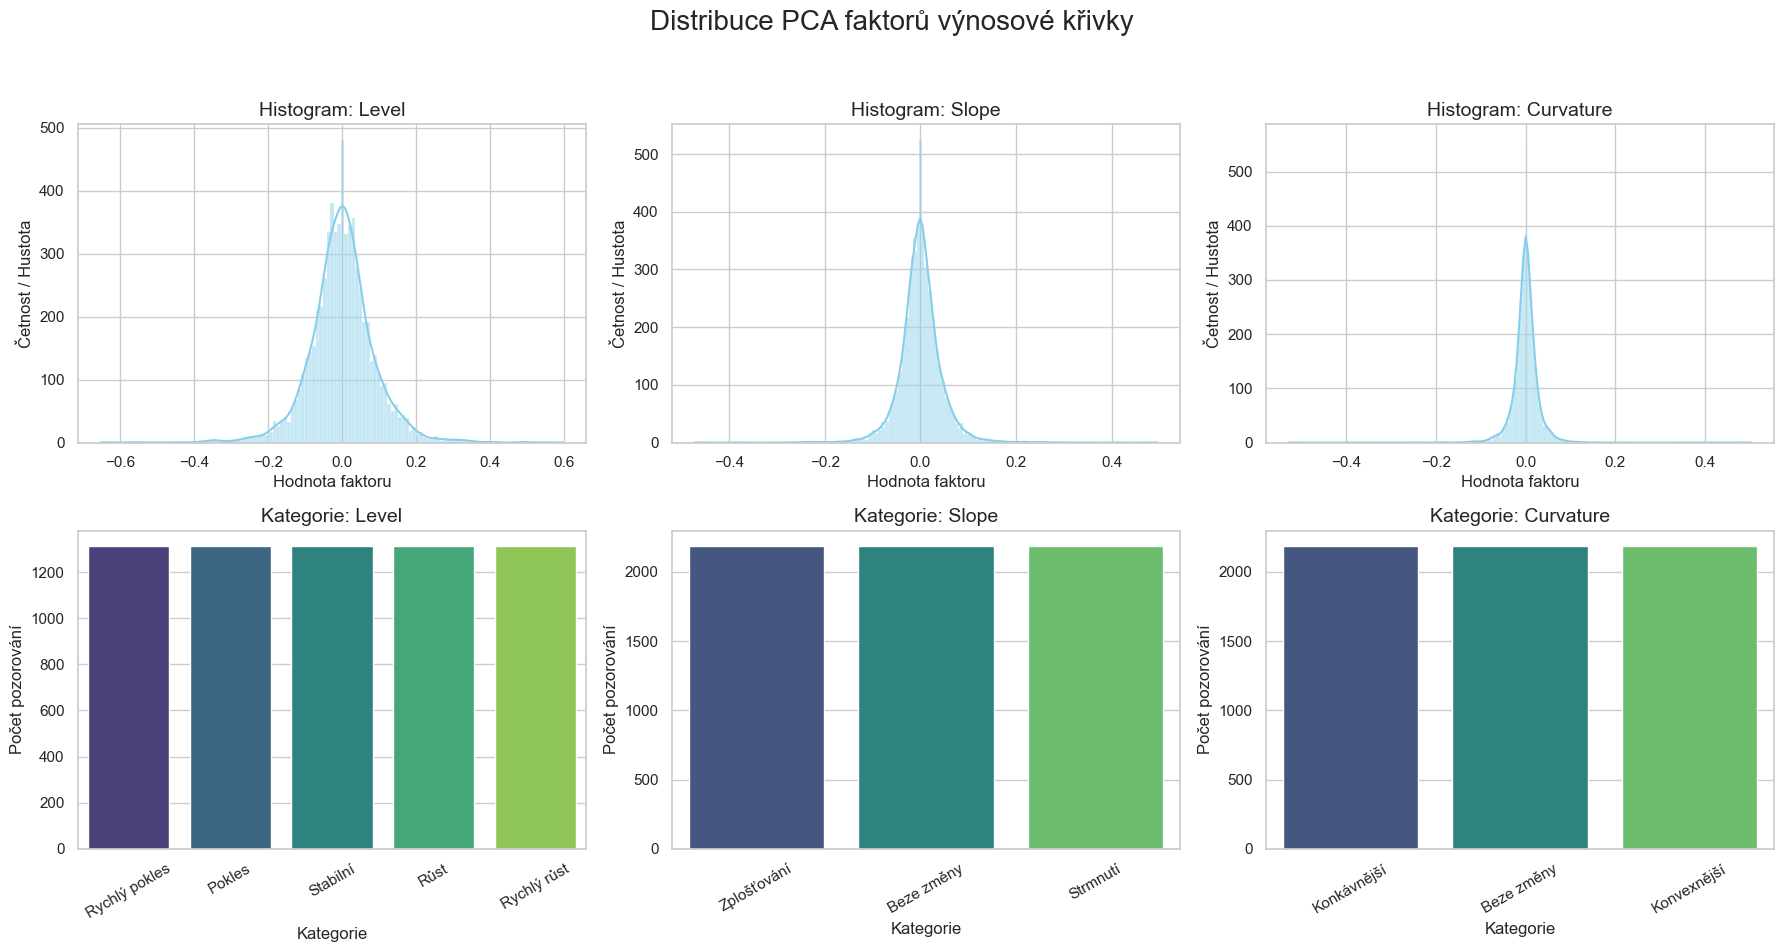

In [435]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribuce PCA faktorů výnosové křivky', fontsize=20)

orders = {
    "level": ["Rychlý pokles", "Pokles", "Stabilní", "Růst", "Rychlý růst"],
    "slope": ["Zplošťování", "Beze změny", "Strmnutí"],
    "curvature": ["Konkávnější", "Beze změny", "Konvexnější"]
}

factors = ["level", "slope", "curvature"]

for i, col in enumerate(factors):
    # 1. Řada: Histogramy pro spojitá číselná data
    sns.histplot(df_factors[col], kde=True, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Histogram: {col.capitalize()}', fontsize=14)
    axes[0, i].set_xlabel('Hodnota faktoru')
    axes[0, i].set_ylabel('Četnost / Hustota')

    # 2. Řada: Countplot pro kategoriální data
    sns.countplot(
        data=df_factors, 
        x=f"{col}_cat", 
        order=orders[col],
        ax=axes[1, i], 
        palette='viridis'
    )
    axes[1, i].set_title(f'Kategorie: {col.capitalize()}', fontsize=14)
    axes[1, i].set_xlabel('Kategorie')
    axes[1, i].set_ylabel('Počet pozorování')
    axes[1, i].tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [470]:
df_factors = df_factors.copy()
# datum jako sloupec bez indexu pro budoucí spojení s legislativou
df_factors = df_factors.reset_index()
df_factors['TIME_PERIOD'] = pd.to_datetime(df_factors['TIME_PERIOD']).dt.tz_localize(None)

In [471]:
# 1) přejmenování hodnot
df_factors['d_Level'] = df_factors['level_cat']
df_factors['d_Slope'] = df_factors['slope_cat']
df_factors['d_Curvature'] = df_factors['curvature_cat']

# pomocné proměnné pro budoucí analýzu
df_factors['d_Slope_Lag1_raw'] = df_factors['slope'].shift(1)
df_factors['Slope_Trend_5d_raw'] = df_factors['slope'].rolling(window=5).sum()
df_factors['Yield_Volat_10d_raw'] = df_factors['level'].rolling(window=10).std()

#kKategorizace pouze těchto nových proměnných
df_factors['Slope_Trend_5d'] = pd.qcut(
    df_factors['Slope_Trend_5d_raw'].dropna().rank(method='first'), q=3,
    labels=['Trend zplošťování', 'Stabilní', 'Trend strmnutí']
)

df_factors['Yield_Volat_10d'] = pd.qcut(
    df_factors['Yield_Volat_10d_raw'].dropna().rank(method='first'), q=3,
    labels=['Nízká', 'Standardní', 'Extrémní']
)

df_factors['d_Slope_Lag1'] = pd.qcut(
    df_factors['d_Slope_Lag1_raw'].dropna().rank(method='first'), q=3,
    labels=['Zplošťování', 'Beze změny', 'Strmnutí']
)

# smazání numerických hodnot
surove_makro_sloupce = ['level', 'slope', 'curvature', 'level_cat', 'slope_cat', 'curvature_cat',
                        'd_Slope_Lag1_raw', 'Slope_Trend_5d_raw', 'Yield_Volat_10d_raw']
df_factors_clean = df_factors.drop(columns=surove_makro_sloupce, errors='ignore')

In [472]:
# 2. přidání tržních dat

# matchne poslední a první datum v datasetu
start_date = df_factors['TIME_PERIOD'].min()
end_date = df_factors['TIME_PERIOD'].max() + pd.Timedelta(days=1)

# přes knihovnu yfinance stáhneme jen DAX, bohužel ostatní proměnné nemají tak dlouhou časovou řadu a nahrjí se z .csv souboru
tickers = ['^GDAXI']
market_raw = yf.download(tickers, start=start_date, end=end_date)

if isinstance(market_raw.columns, pd.MultiIndex):
    market_data = market_raw['Close'].copy()
else:
    market_data = market_raw.copy()

market_data = market_data.reset_index()
market_data.rename(columns={
    market_data.columns[0]: 'Date',
    '^GDAXI': 'DAX_Close'
}, inplace=True)

market_data['Date'] = pd.to_datetime(market_data['Date']).dt.tz_localize(None)

[*********************100%***********************]  1 of 1 completed


In [473]:
# Načtení VDAX
vdax_df_clean = vdax_df[['Date', 'Price']].copy()
vdax_df_clean.rename(columns={'Price': 'VDAX_Close'}, inplace=True)
vdax_df_clean['Date'] = pd.to_datetime(vdax_df_clean['Date'], format='%m/%d/%y').dt.tz_localize(None)

# Načtení EURUSD 
eurusd_df.rename(columns={'Price': 'EURUSD_Close'}, inplace=True)
eurusd_df['Date'] = pd.to_datetime(eurusd_df['Date'], format='%m/%d/%y').dt.tz_localize(None)

# Spojení všech tržních dat
market_data = pd.merge(market_data, vdax_df_clean, on='Date', how='left')
market_data = pd.merge(market_data, eurusd_df, on='Date', how='left')

# výplň výkendů a chybějících dní
market_data = market_data.ffill()

# A) výpočty procentuálních změn a klouzavých oken
market_data['DAX_Return'] = market_data['DAX_Close'].pct_change(fill_method=None) * 100
market_data['EURUSD_Pct'] = market_data['EURUSD_Close'].pct_change(fill_method=None)
market_data['DAX_Volat_raw'] = market_data['DAX_Return'].rolling(window=5).std()
market_data['SMA_20'] = market_data['DAX_Close'].rolling(window=20).mean()

# B) kategorizace 
market_data['DAX_Return_Cat'] = pd.cut(
    market_data['DAX_Return'], 
    bins=[-float('inf'), -2.0, -0.5, 0.5, 2.0, float('inf')],
    labels=['Crash (<-2 %)', 'Pokles', 'Stabilní', 'Růst', 'Boom (>+2 %)']
)

market_data['DAX_Volat_5d'] = pd.qcut(
    market_data['DAX_Volat_raw'].dropna().rank(method='first'), q=3,
    labels=['Klidný trh', 'Standard', 'Panika']
)

market_data['DAX_Momentum'] = pd.Series(dtype='object')
ma_exists = market_data['SMA_20'].notna()
market_data.loc[ma_exists & (market_data['DAX_Close'] > market_data['SMA_20']), 'DAX_Momentum'] = 'Nad průměrem'
market_data.loc[ma_exists & (market_data['DAX_Close'] <= market_data['SMA_20']), 'DAX_Momentum'] = 'Pod průměrem'

market_data['VDAX_Category'] = pd.cut(
    market_data['VDAX_Close'], 
    bins=[0, 17.5, 26.0, float('inf')],
    labels=['Klid', 'Zvýšené riziko', 'Extrémní strach'],
    right=False
)

market_data['EURUSD_Return'] = pd.qcut(
    market_data['EURUSD_Pct'].dropna().rank(method='first'), q=3,
    labels=['Oslabení EUR', 'Stabilní', 'Posílení EUR']
)

# smazání numerických hodnot
sloupce_k_odstraneni = ['DAX_Close', 'VDAX_Close', 'EURUSD_Close', 'EURUSD_Pct', 'DAX_Volat_raw', 'SMA_20']
market_data_clean = market_data.drop(columns=sloupce_k_odstraneni, errors='ignore')

In [474]:
#  3 spojení datasetů a vytvoření proměnných
df_merged = pd.merge(
    left=market_data_clean, 
    right=df_factors_clean, 
    left_on='Date', 
    right_on='TIME_PERIOD', 
    how='inner'
)
df_merged = df_merged.drop(columns=['TIME_PERIOD'], errors='ignore')

In [475]:
# 4. legislativa
df_mistral['Document_Date'] = pd.to_datetime(df_mistral['Document_Date']).dt.tz_localize(None)

# výběr atributů
legislative_cols = ['Document_Date', 'Celex_Number', 'Form', 'Primary_Sector', 'Impact_Intensity', 'Strictness', 'Time_Horizon', 'Complexity']
df_mistral_clean = df_mistral[legislative_cols].copy()

# spojení legistlativy a tržních dat
df_final = pd.merge(
    left=df_merged,
    right=df_mistral_clean,
    left_on='Date',
    right_on='Document_Date',
    how='inner'
)
df_final = df_final.drop(columns=['Document_Date'], errors='ignore')
df_final = df_final.sort_values(by=['Date', 'Celex_Number']).reset_index(drop=True)

In [476]:
# 5 sezažení pro přehlednost
struktura_sloupcu = [
    'Date', 'Celex_Number',
    # A. Makroekonomické
    'd_Level', 'd_Slope', 'd_Curvature', 'Slope_Trend_5d', 'Yield_Volat_10d', 'd_Slope_Lag1',
    # B. Legislativní
    'Form', 'Primary_Sector', 'Impact_Intensity', 'Strictness', 'Time_Horizon', 'Complexity',
    # C. Akciový trh 
    'DAX_Return_Cat', 'DAX_Volat_5d', 'DAX_Momentum', 'VDAX_Category',
    # D. Kurz
    'EURUSD_Return'
]

df_final = df_final[struktura_sloupcu]

In [492]:
df_final['Form'].unique()

array(['Rozhodnutí', 'Směrnice', 'Nařízení', 'Rámcové rozhodnutí',
       'Usnesení', 'Doporučení', 'Stanovisko', 'Obecné zásady', 'Dohoda',
       'Mezinárodní dohoda', 'Interinstitucionální dohoda', 'Rozpočet',
       'Dohoda mezi členskými státy', 'Sdělení',
       'Nařízení přijaté institucemi zřízenými mezinárodní dohodou',
       'Prováděcí rozhodnutí', 'Nařízení v přenesené pravomoci',
       'Prováděcí nařízení', 'Dodatek', 'Prováděcí směrnice',
       'Rozhodnutí v přenesené pravomoci', 'Jednací řád',
       'Směrnice v přenesené pravomoci'], dtype=object)

In [478]:
mapping_dict = {
    # 1. Nařízení
    'Nařízení': 'Nařízení',
    'Prováděcí nařízení': 'Nařízení',
    'Nařízení v přenesené pravomoci': 'Nařízení',
    'Nařízení přijaté institucemi zřízenými mezinárodní dohodou': 'Nařízení',
    
    # 2. Směrnice
    'Směrnice': 'Směrnice',
    'Prováděcí směrnice': 'Směrnice',
    'Směrnice v přenesené pravomoci': 'Směrnice',
    
    # 3. Rozhodnutí
    'Rozhodnutí': 'Rozhodnutí',
    'Prováděcí rozhodnutí': 'Rozhodnutí',
    'Rozhodnutí v přenesené pravomoci': 'Rozhodnutí',
    'Rámcové rozhodnutí': 'Rozhodnutí',
    
    # 4. Jiné
    'Dohoda': 'Jiné',
    'Mezinárodní dohoda': 'Jiné',
    'Interinstitucionální dohoda': 'Jiné',
    'Dohoda mezi členskými státy': 'Jiné',
    'Doporučení': 'Jiné',
    'Stanovisko': 'Jiné',
    'Sdělení': 'Jiné',
    'Usnesení': 'Jiné',
    'Obecné zásady': 'Jiné',
    'Rozpočet': 'Jiné',
    'Dodatek': 'Jiné',
    'Jednací řád': 'Jiné'
}

df_final['Act_Type'] = df_final['Form'].map(mapping_dict)

In [479]:
df_final.head()

,Date,Celex_Number,d_Level,d_Slope,d_Curvature,Slope_Trend_5d,Yield_Volat_10d,d_Slope_Lag1,Form,Primary_Sector,Impact_Intensity,Strictness,Time_Horizon,Complexity,DAX_Return_Cat,DAX_Volat_5d,DAX_Momentum,VDAX_Category,EURUSD_Return,Act_Type
0,2000-08-03,32000R1729,Rychlý růst,Strmnutí,Beze změny,NaN,NaN,Beze změny,Nařízení,Průmysl,3,4,Dlouhodobý,4,Pokles,NaN,NaN,NaN,Oslabení EUR,Nařízení
1,2000-08-08,32002D0696,Růst,Beze změny,Beze změny,Trend strmnutí,NaN,Strmnutí,Rozhodnutí,Finance,4,5,Dlouhodobý,5,Stabilní,NaN,NaN,NaN,Oslabení EUR,Rozhodnutí
2,2000-08-11,32000R1773,Růst,Zplošťování,Konkávnější,Trend zplošťování,NaN,Zplošťování,Nařízení,Průmysl,3,3,Krátkodobý,4,Růst,Klidný trh,NaN,NaN,Oslabení EUR,Nařízení
3,2000-08-16,32000R1778,Rychlý růst,Beze změny,Beze změny,Trend zplošťování,Standardní,Strmnutí,Nařízení,Finance,3,5,Okamžitý,3,Stabilní,Klidný trh,NaN,NaN,Posílení EUR,Nařízení
4,2000-08-23,32000X0823,Pokles,Beze změny,Beze změny,Trend zplošťování,Standardní,Strmnutí,Seznam,Průmysl,5,5,Dlouhodobý,5,Stabilní,Klidný trh,NaN,NaN,Posílení EUR,NaN


In [480]:
print(df_final.isna().sum())

Date                  0
Celex_Number          0
d_Level               0
d_Slope               0
d_Curvature           0
Slope_Trend_5d        1
Yield_Volat_10d       3
d_Slope_Lag1          0
Form                  0
Primary_Sector        0
Impact_Intensity      0
Strictness            0
Time_Horizon          0
Complexity            0
DAX_Return_Cat        0
DAX_Volat_5d          2
DAX_Momentum          5
VDAX_Category       334
EURUSD_Return         0
Act_Type              3
dtype: int64


Data pro VDAX jsou dostupná od roku 2001, proto budeme pracovat s datasetem v roce 2001 (jedná se o slice ze začátku časového období proto není třeba se tolik obávat selectivity bias)

In [481]:
df_final.dropna(inplace=True)
df_final.to_csv("final.csv", index=False, sep=';', encoding='utf-8-sig', header=True)

In [488]:
df_final

,Date,Celex_Number,d_Level,d_Slope,d_Curvature,Slope_Trend_5d,Yield_Volat_10d,d_Slope_Lag1,Form,Primary_Sector,Impact_Intensity,Strictness,Time_Horizon,Complexity,DAX_Return_Cat,DAX_Volat_5d,DAX_Momentum,VDAX_Category,EURUSD_Return,Act_Type
334,2001-05-14,32001D0395,Rychlý růst,Strmnutí,Konvexnější,Trend strmnutí,Extrémní,Strmnutí,Rozhodnutí,Průmysl,4,5,Dlouhodobý,4,Pokles,Standard,Pod průměrem,Zvýšené riziko,Stabilní,Rozhodnutí
335,2001-05-15,32001D0387,Stabilní,Strmnutí,Beze změny,Trend strmnutí,Extrémní,Strmnutí,Rozhodnutí,Finance,3,3,Krátkodobý,3,Stabilní,Standard,Pod průměrem,Zvýšené riziko,Posílení EUR,Rozhodnutí
336,2001-05-15,32002D0324,Stabilní,Strmnutí,Beze změny,Trend strmnutí,Extrémní,Strmnutí,Rozhodnutí,Finance,4,4,Dlouhodobý,4,Stabilní,Standard,Pod průměrem,Zvýšené riziko,Posílení EUR,Rozhodnutí
337,2001-05-22,32001D0423,Pokles,Strmnutí,Konkávnější,Trend zplošťování,Extrémní,Zplošťování,Rozhodnutí,Průmysl,3,3,Dlouhodobý,4,Stabilní,Klidný trh,Nad průměrem,Zvýšené riziko,Oslabení EUR,Rozhodnutí
338,2001-05-22,32001D0516,Pokles,Strmnutí,Konkávnější,Trend zplošťování,Extrémní,Zplošťování,Rozhodnutí,Jiné,3,3,Střednědobý,4,Stabilní,Klidný trh,Nad průměrem,Zvýšené riziko,Oslabení EUR,Rozhodnutí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10383,2026-04-27,32026D1029,Rychlý pokles,Strmnutí,Beze změny,Trend zplošťování,Standardní,Zplošťování,Rozhodnutí,Životní prostředí,4,4,Střednědobý,4,Stabilní,Klidný trh,Nad průměrem,Zvýšené riziko,Stabilní,Rozhodnutí
10384,2026-04-27,32026D1067,Rychlý pokles,Strmnutí,Beze změny,Trend zplošťování,Standardní,Zplošťování,Rozhodnutí,Životní prostředí,4,4,Střednědobý,4,Stabilní,Klidný trh,Nad průměrem,Zvýšené riziko,Stabilní,Rozhodnutí
10385,2026-04-29,32026R1030,Rychlý růst,Zplošťování,Beze změny,Trend zplošťování,Standardní,Zplošťování,Nařízení,Životní prostředí,4,4,Dlouhodobý,4,Stabilní,Klidný trh,Nad průměrem,Zvýšené riziko,Oslabení EUR,Nařízení
10386,2026-05-04,32026D0994,Rychlý pokles,Strmnutí,Konkávnější,Trend zplošťování,Extrémní,Zplošťování,Rozhodnutí,Energetika,3,4,Dlouhodobý,4,Pokles,Standard,Pod průměrem,Zvýšené riziko,Oslabení EUR,Rozhodnutí


# CLEVER MINER

## 1.1 Pre-Processing

In [482]:
df = df_final.copy()

# 1. úroková křivka
df['d_Level'] = df['d_Level'].astype(CategoricalDtype(
    categories=['Rychlý pokles', 'Pokles', 'Stabilní', 'Růst', 'Rychlý růst'], ordered=True))

df['d_Slope'] = df['d_Slope'].astype(CategoricalDtype(
    categories=['Zplošťování', 'Beze změny', 'Strmnutí'], ordered=True))

df['d_Curvature'] = df['d_Curvature'].astype(CategoricalDtype(
    categories=['Konkávnější', 'Beze změny', 'Konvexnější'], ordered=True))

df['Slope_Trend_5d'] = df['Slope_Trend_5d'].astype(CategoricalDtype(
    categories=['Trend zplošťování', 'Stabilní', 'Trend strmnutí'], ordered=True))

df['Yield_Volat_10d'] = df['Yield_Volat_10d'].astype(CategoricalDtype(
    categories=['Nízká', 'Standardní', 'Extrémní'], ordered=True))

df['d_Slope_Lag1'] = df['d_Slope_Lag1'].astype(CategoricalDtype(
    categories=['Zplošťování', 'Beze změny', 'Strmnutí'], ordered=True))


# 2. trh
df['DAX_Return_Cat'] = df['DAX_Return_Cat'].astype(CategoricalDtype(
    categories=['Crash (<-2 %)', 'Pokles', 'Stabilní', 'Růst', 'Boom (>+2 %)'], ordered=True))

df['DAX_Volat_5d'] = df['DAX_Volat_5d'].astype(CategoricalDtype(
    categories=['Klidný trh', 'Standard', 'Panika'], ordered=True))

df['DAX_Momentum'] = df['DAX_Momentum'].astype(CategoricalDtype(
    categories=['Pod průměrem', 'Nad průměrem'], ordered=True))

df['VDAX_Category'] = df['VDAX_Category'].astype(CategoricalDtype(
    categories=['Klid', 'Zvýšené riziko', 'Extrémní strach'], ordered=True))

df['EURUSD_Return'] = df['EURUSD_Return'].astype(CategoricalDtype(
    categories=['Oslabení EUR', 'Stabilní', 'Posílení EUR'], ordered=True))


# 3. legislativa
df['Time_Horizon'] = df['Time_Horizon'].astype(CategoricalDtype(
    categories=['Okamžitý', 'Střednědobý', 'Dlouhodobý'], ordered=True))

df['Impact_Intensity'] = df['Impact_Intensity'].astype(CategoricalDtype(
    categories=[1, 2, 3, 4, 5], ordered=True))

df['Strictness'] = df['Strictness'].astype(CategoricalDtype(
    categories=[1, 2, 3, 4, 5], ordered=True))

df['Complexity'] = df['Complexity'].astype(CategoricalDtype(
    categories=[1, 2, 3, 4, 5], ordered=True))

## 1.2 Data science

4ftMiner

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:00
Done. Total verifications : 169, rules 11, times: prep 0.16sec, processing 0.04sec

List of rules:
RULEID BASE  CONF  AAD    Rule
     1    28 0.438 +0.287 Primary_Sector(Energetika) & Act_Type(Jiné) => d_Slope(Beze změny) | ---
     2    26 0.406 +0.157 Primary_Sector(Energetika) & Act_Type(Jiné) => d_Curvature(Beze změny) | ---
     3    81 0.424 +0.208 Primary_Sector(Energetika) & Act_Type(Nařízení) => d_Curvature(Beze změny) | ---
     4    63 0.423 +0.242 Primary_Sector(Finance) & Act_Type(Jiné) => d_Curvature(Konkávnější) | ---
     5    20 0.417 +0.240 Primary_Sector(Finance) & Act_Type(Směrnice) => d_Sl

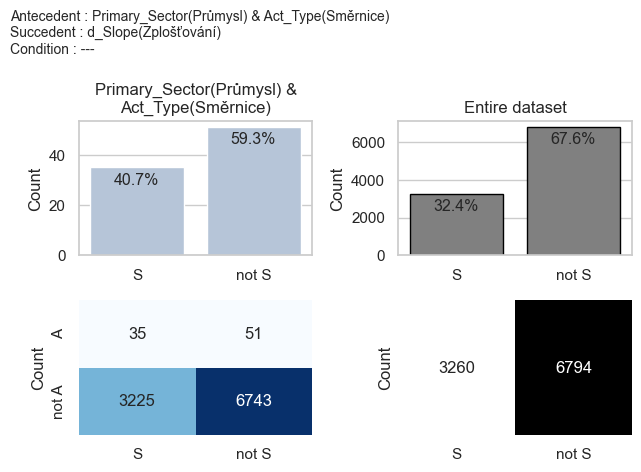

In [494]:
cm1 = cleverminer(df=df, proc='4ftMiner',
    quantifiers={'Base': 20, 'conf': 0.40},
    ante={
            'attributes': [
                {'name': 'Primary_Sector', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                {'name': 'Act_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            ],
            'minlen': 2, 'maxlen': 2, 'type': 'con' 
        },
    succ={
        'attributes': [
            {'name': 'd_Slope', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            {'name': 'd_Level', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            {'name': 'd_Curvature', 'type': 'subset', 'minlen': 1, 'maxlen': 1}
        ],
        'minlen': 1, 'maxlen': 1, 'type': 'con' 
    }
)

cm1.print_rulelist()
cm1.draw_rule(10)

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:00
Done. Total verifications : 151, rules 7, times: prep 0.22sec, processing 0.05sec

List of rules:
RULEID BASE  CONF  AAD    Rule
     1    86 0.450 +0.341 Primary_Sector(Energetika) & Act_Type(Nařízení) => Yield_Volat_10d(Nízká) | ---
     2    21 0.477 +0.437 Primary_Sector(Energetika) & Act_Type(Směrnice) => Slope_Trend_5d(Trend zplošťování) | ---
     3    20 0.455 +0.479 Primary_Sector(Energetika) & Act_Type(Směrnice) => Yield_Volat_10d(Standardní) | ---
     4    73 0.490 +0.595 Primary_Sector(Finance) & Act_Type(Jiné) => Yield_Volat_10d(Standardní) | ---
     5    73 0.490 +0.491 Primary_Sector(Finance) &

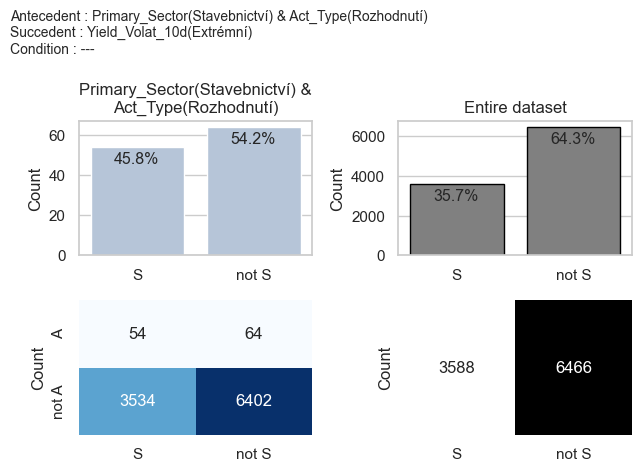

In [495]:
cm2 = cleverminer(df=df, proc='4ftMiner',
    quantifiers={'Base': 20, 'conf': 0.45},
    ante={
            'attributes': [
                {'name': 'Primary_Sector', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                {'name': 'Act_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            ],
            'minlen': 2, 'maxlen': 2, 'type': 'con' 
        },
    succ={
        'attributes': [
            {'name': 'Slope_Trend_5d', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            {'name': 'Yield_Volat_10d', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            {'name': 'd_Slope_Lag1', 'type': 'subset', 'minlen': 1, 'maxlen': 1}
        ],
        'minlen': 1, 'maxlen': 1, 'type': 'con' 
    }
)

cm2.print_rulelist()
cm2.draw_rule(7)

SD4ftMiner

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  SD4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:0000
Done. Total verifications : 361, rules 14, times: prep 0.16sec, processing 0.10sec

List of rules:
RULEID BASE1 BASE2 RatioConf DeltaConf Rule
     1   127   137    1.173    +0.050  d_Slope(Beze změny) => d_Level(Stabilní) | --- : Primary_Sector(Jiné) x Primary_Sector(Průmysl)
     2   127   276    1.160    +0.046  d_Slope(Beze změny) => d_Level(Stabilní) | --- : Primary_Sector(Jiné) x Strictness(2 3)
     3   127   259    1.160    +0.047  d_Slope(Beze změny) => d_Level(Stabilní) | --- : Primary_Sector(Jiné) x Strictness(3)
     4   488   137    1.136    +0.039  d_Slope(Beze změny) => d_Level(Stabilní) | --

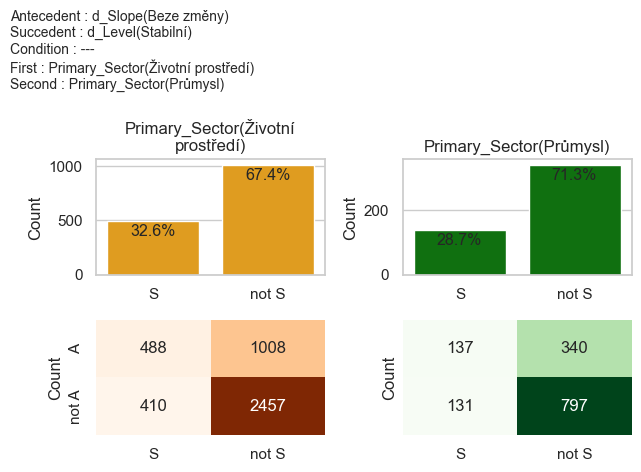

In [503]:
cm3 = cleverminer(df=df, proc='SD4ftMiner',
    quantifiers={'Base1': 100, 'Base2': 100, 'ratioconf': 1.12}, 
    frst={
            'attributes': [
                {'name': 'Primary_Sector', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                {'name': 'Act_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                {'name': 'Strictness', 'type': 'seq', 'minlen': 1, 'maxlen': 2},
            ],
            'minlen': 1, 'maxlen': 1, 'type': 'con' 
        },
    scnd={
            'attributes': [
                {'name': 'Primary_Sector', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                {'name': 'Act_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
                {'name': 'Strictness', 'type': 'seq', 'minlen': 1, 'maxlen': 2},
            ],
            'minlen': 1, 'maxlen': 1, 'type': 'con' 
        },
    
    ante={
        'attributes': [{'name': 'd_Slope', 'type': 'one', 'value': 'Beze změny'}],
        'minlen': 1, 'maxlen': 1, 'type': 'con'
    },
    
    succ={
        'attributes': [{'name': 'd_Level', 'type': 'one', 'value': 'Stabilní'}],
        'minlen': 1, 'maxlen': 1, 'type': 'con'
    }
)

cm3.print_rulelist()
cm3.draw_rule(4)

CF-MINER

Cleverminer version 1.2.4.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  CFMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:00
Done. Total verifications : 47, rules 13, times: prep 0.11sec, processing 0.03sec

List of rules:
RULEID BASE  S_UP  S_DOWN Condition
     1   397     3     0 Complexity(5) & Primary_Sector(Energetika)
     2  1142     3     0 Complexity(5) & Primary_Sector(Finance)
     3   539     3     0 Complexity(5) & Primary_Sector(Průmysl)
     4    61     3     0 Complexity(5) & Primary_Sector(Stavebnictví)
     5  1462     3     0 Complexity(5) & Act_Type(Nařízení)
     6  1969     3     0 Complexity(5) & Act_Type(Rozhodnutí)
     7    64     3     0 Primary_Sector(Energetika) & Act_Type(Jiné)
     8   474     3     1 P

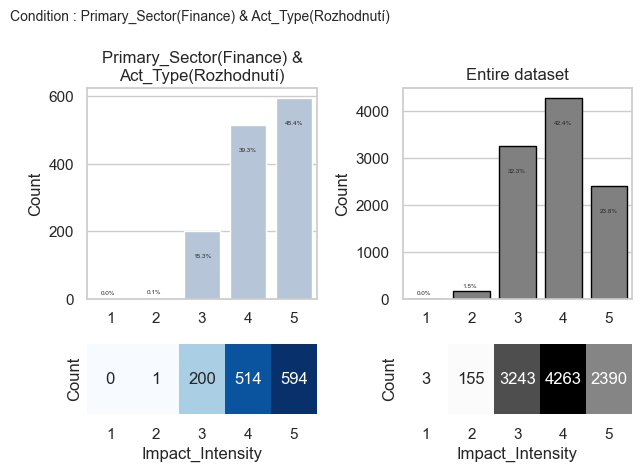

In [508]:
cm4 = cleverminer(df=df, proc='CFMiner',
    quantifiers={'Base': 50, 'S_Up': 3}, 
    cond={
        'attributes': [
            {'name': 'Complexity', 'type': 'subset', 'minlen': 1, 'maxlen': 1}, 
            {'name': 'Primary_Sector', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            {'name': 'Act_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1}
        ],
        'minlen': 2, 'maxlen': 2, 'type': 'con' 
    },
    target='Impact_Intensity'
)
cm4.print_rulelist()

cm5 = cleverminer(df=df, proc='CFMiner',
    quantifiers={'Base': 50, 'S_Down': 3}, 
    cond={
        'attributes': [
            {'name': 'Complexity', 'type': 'subset', 'minlen': 1, 'maxlen': 1}, 
            {'name': 'Primary_Sector', 'type': 'subset', 'minlen': 1, 'maxlen': 1},
            {'name': 'Act_Type', 'type': 'subset', 'minlen': 1, 'maxlen': 1}
        ],
        'minlen': 2, 'maxlen': 2, 'type': 'con' 
    },
    target='Impact_Intensity'
)
cm5.print_rulelist()
cm4.draw_rule(9)

Decision Tree

Legislativa
              precision    recall  f1-score   support

  Beze změny       0.36      0.34      0.35       656
    Strmnutí       0.31      0.44      0.36       608
 Zplošťování       0.37      0.23      0.28       639

    accuracy                           0.34      1903
   macro avg       0.35      0.34      0.33      1903
weighted avg       0.35      0.34      0.33      1903

Trh
              precision    recall  f1-score   support

  Beze změny       0.37      0.68      0.48       656
    Strmnutí       0.39      0.25      0.31       608
 Zplošťování       0.32      0.16      0.21       639

    accuracy                           0.37      1903
   macro avg       0.36      0.36      0.33      1903
weighted avg       0.36      0.37      0.34      1903



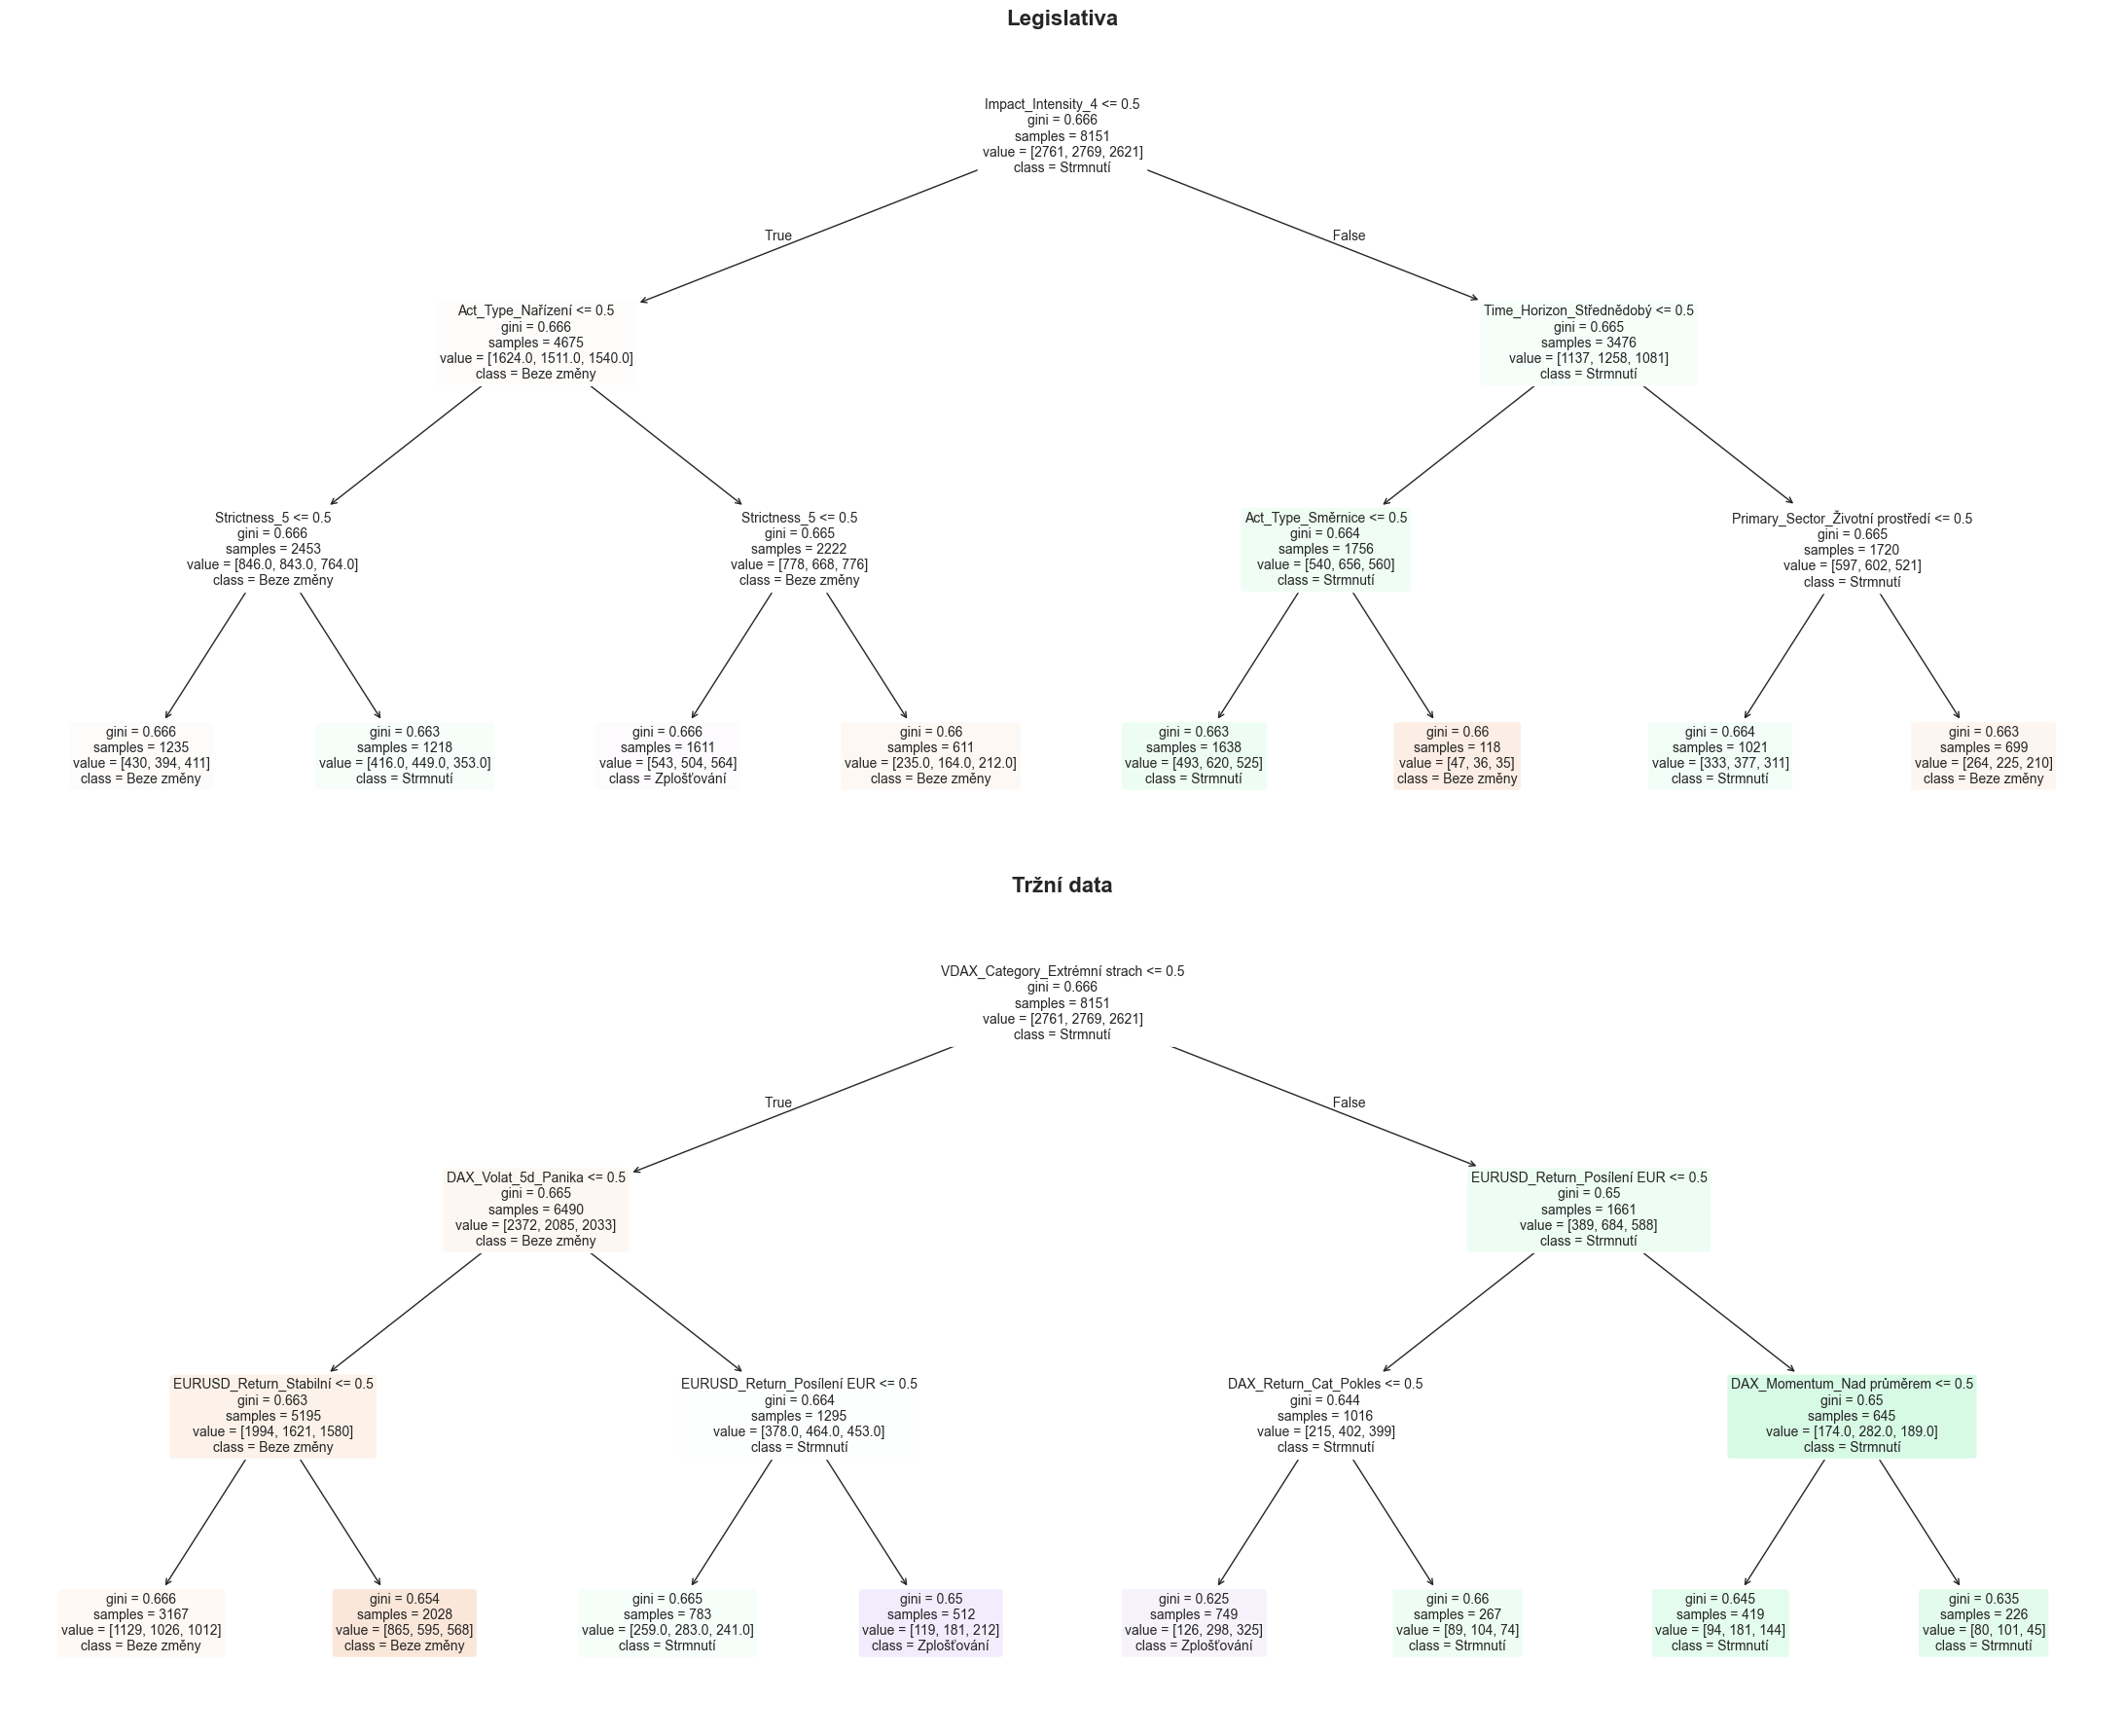

In [486]:
X_leg_raw = df[['Primary_Sector', 'Act_Type', 'Complexity', 'Strictness', 'Impact_Intensity', 'Time_Horizon']]
X_mkt_raw = df[['DAX_Return_Cat', 'DAX_Volat_5d', 'DAX_Momentum', 'VDAX_Category', 'EURUSD_Return']]
y = df['d_Slope']
# one hot Encoding
X_leg = pd.get_dummies(X_leg_raw, drop_first=True)
X_mkt = pd.get_dummies(X_mkt_raw, drop_first=True)


# definováni datumu kvůli flat datasetu (split 80/20)
groups = df['Date'] 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_mkt, y, groups=groups))

# rozdělení tržních dat
X_mkt_train, X_mkt_test = X_mkt.iloc[train_idx], X_mkt.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# rozdělení legislativních dat podle stejných indexů
X_leg_train, X_leg_test = X_leg.iloc[train_idx], X_leg.iloc[test_idx]

# trénování (pro přehlednost hloubka 3)
clf_leg = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_leg.fit(X_leg_train, y_train)
y_leg_pred = clf_leg.predict(X_leg_test)


clf_mkt = DecisionTreeClassifier(max_depth=3, random_state=42)
clf_mkt.fit(X_mkt_train, y_train)
y_mkt_pred = clf_mkt.predict(X_mkt_test)

print('Legislativa')
print(classification_report(y_test, y_leg_pred))
print('Trh')
print(classification_report(y_test, y_mkt_pred))


# 5. vykreslení
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(22, 18))

plot_tree(clf_leg, feature_names=X_leg.columns, class_names=clf_leg.classes_.astype(str), 
          filled=True, rounded=True, fontsize=10, ax=axes[0])
axes[0].set_title("Legislativa", fontsize=16, fontweight='bold')

plot_tree(clf_mkt, feature_names=X_mkt.columns, class_names=clf_mkt.classes_.astype(str), 
          filled=True, rounded=True, fontsize=10, ax=axes[1])
axes[1].set_title("Tržní data", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()